<a href="https://colab.research.google.com/github/Debapri/git-advanced/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Taks1**

In [ ]:
# Robust Colab loader + quick cleaner with diagnostics
import pandas as pd, numpy as np, os, traceback, csv, zipfile
from google.colab import files

print("📁 Upload your dataset now (CSV / XLSX / ZIP).")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

def show_file_head(fname, n=5):
    print("\n--- Raw first lines (bytes) ---")
    try:
        with open(fname, 'rb') as f:
            for i, line in enumerate(f.readlines()[:n]):
                print(i+1, line[:500])
    except Exception as e:
        print("Couldn't read raw lines:", e)

def try_read(fname):
    attempts = []
    lower = fname.lower()

    # Excel
    if lower.endswith(('.xlsx', '.xls')):
        try:
            df = pd.read_excel(fname)
            return df, "pd.read_excel"
        except Exception:
            attempts.append(("pd.read_excel", traceback.format_exc()))

    # ZIP (try to find a CSV inside)
    if lower.endswith('.zip'):
        try:
            with zipfile.ZipFile(fname) as z:
                files_in_zip = z.namelist()
                print("ZIP contains:", files_in_zip)
                for f in files_in_zip:
                    if f.lower().endswith('.csv'):
                        z.extract(f)
                        df = pd.read_csv(f, on_bad_lines='skip', engine='python')
                        return df, f"zip->{f}"
            attempts.append(("zip", "no csv file found inside"))
        except Exception:
            attempts.append(("zip", traceback.format_exc()))

    # Try default CSV read
    try:
        df = pd.read_csv(fname)
        return df, "pd.read_csv (default)"
    except Exception:
        attempts.append(("pd.read_csv default", traceback.format_exc()))

    # Try multiple encodings
    for enc in ('utf-8','latin1','iso-8859-1','cp1252'):
        try:
            df = pd.read_csv(fname, encoding=enc)
            return df, f"pd.read_csv encoding={enc}"
        except Exception:
            attempts.append((f"pd.read_csv encoding={enc}", traceback.format_exc()))

    # Try delimiter sniffing
    try:
        with open(fname, 'r', encoding='utf-8', errors='replace') as f:
            sample = f.read(2048)
        dialect = csv.Sniffer().sniff(sample, delimiters=[',',';','\t','|'])
        sep = dialect.delimiter
        try:
            df = pd.read_csv(fname, sep=sep, engine='python', on_bad_lines='skip')
            return df, f"pd.read_csv sep={sep}"
        except Exception:
            attempts.append((f"sniffer sep={sep}", traceback.format_exc()))
    except Exception:
        attempts.append(("sniffer", "could not sniff delimiter"))

    # Final fallback
    try:
        df = pd.read_table(fname, engine='python', on_bad_lines='skip')
        return df, "pd.read_table fallback"
    except Exception:
        attempts.append(("pd.read_table", traceback.format_exc()))

    return None, attempts

# Show raw preview
show_file_head(filename)

# Attempt reads
df, info = try_read(filename)
if df is None:
    print("\n❌ Could not read the file. Attempts and tracebacks:")
    for tag, tb in info:
        print("\n--- Attempt:", tag, "---")
        print(tb)
    raise SystemExit("Reading failed. Inspect tracebacks above and adjust file/format.")

print("\n✅ File loaded using:", info)
print("Shape:", df.shape)
print(df.head())

# ===== Quick, safe cleaning =====
df = df.drop_duplicates()

# Convert numeric-ish columns safely
for col in df.select_dtypes(include=['object','int','float']).columns:
    # try to coerce columns that contain numeric-like strings
    try:
        coerced = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d\.-]', '', regex=True), errors='coerce')
        # if many values became numeric (heuristic), keep numeric
        if coerced.notna().sum() > (len(df) * 0.3):
            df[col] = coerced
    except Exception:
        pass

# Numeric columns: fill median
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Text columns: safe string ops
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col].replace({'nan':'unknown','none':'unknown'}, inplace=True)
    df[col].fillna('unknown', inplace=True)

# Date-like columns: try to parse
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("\n--- After cleaning ---")
print(df.info())
print(df.head())

# Save and provide download
out_name = 'cleaned_data.csv'
df.to_csv(out_name, index=False)
print(f"\n✅ Cleaned file saved to {out_name}. Downloading...")
files.download(out_name)


📁 Upload your dataset now (CSV / XLSX / ZIP).


Saving customers-100.csv.xlsx to customers-100.csv (3).xlsx
Uploaded file: customers-100.csv (3).xlsx

--- Raw first lines (bytes) ---
1 b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

/tmp/ipython-input-2988450300.py:117: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2988450300.py:123: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Task2**

Shape of dataset: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Summary Stats:
         PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000   

/tmp/ipython-input-3065503705.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-3065503705.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

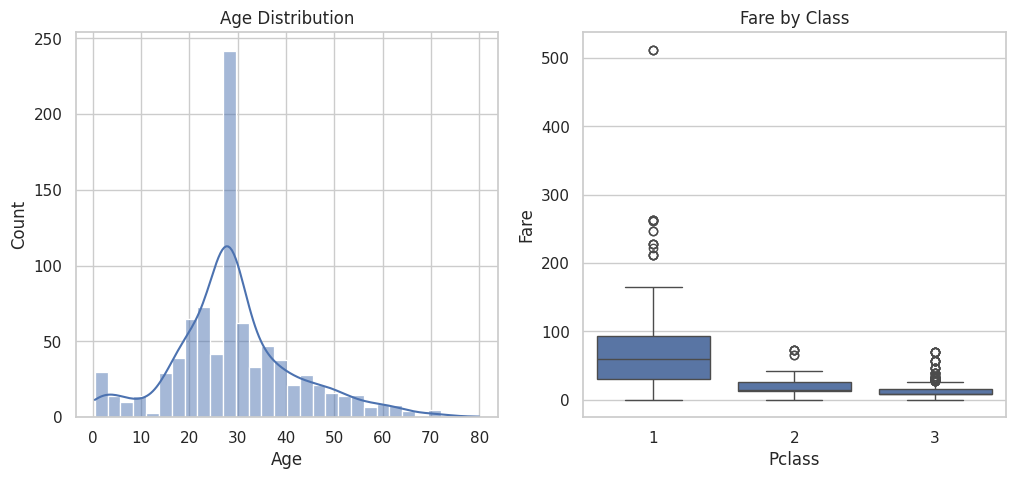

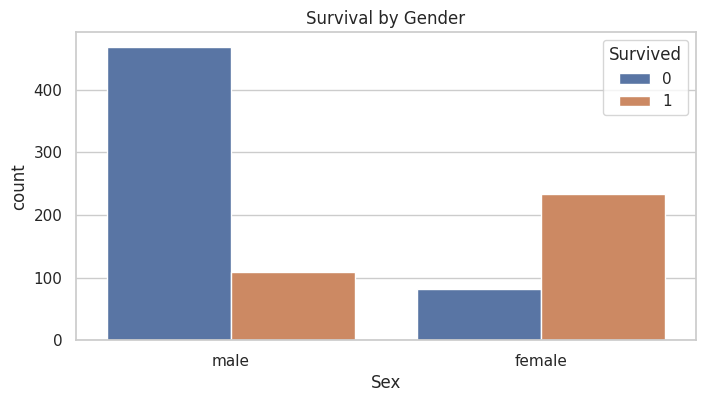

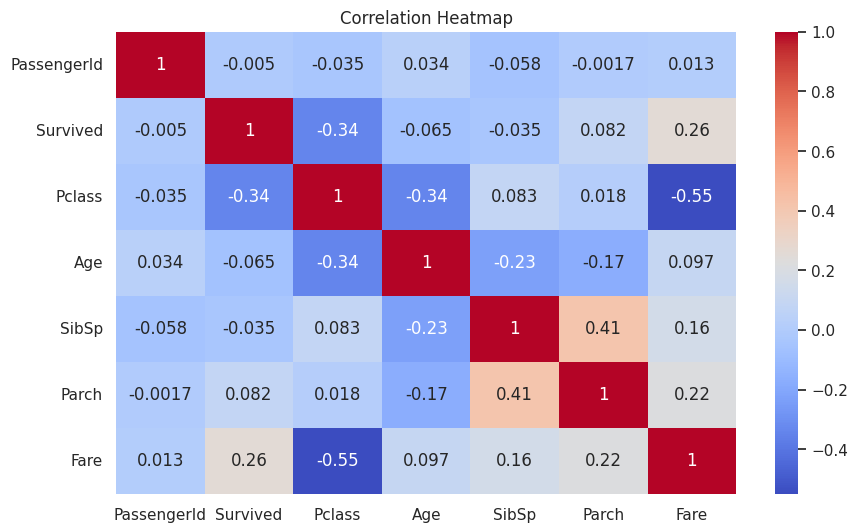


Pclass vs Survived (%):

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


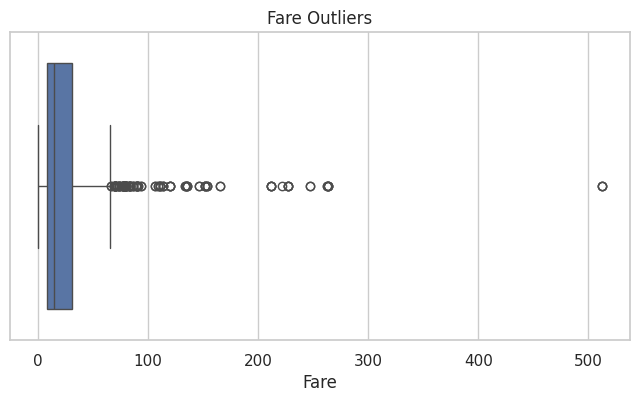

Found 20 fare outliers


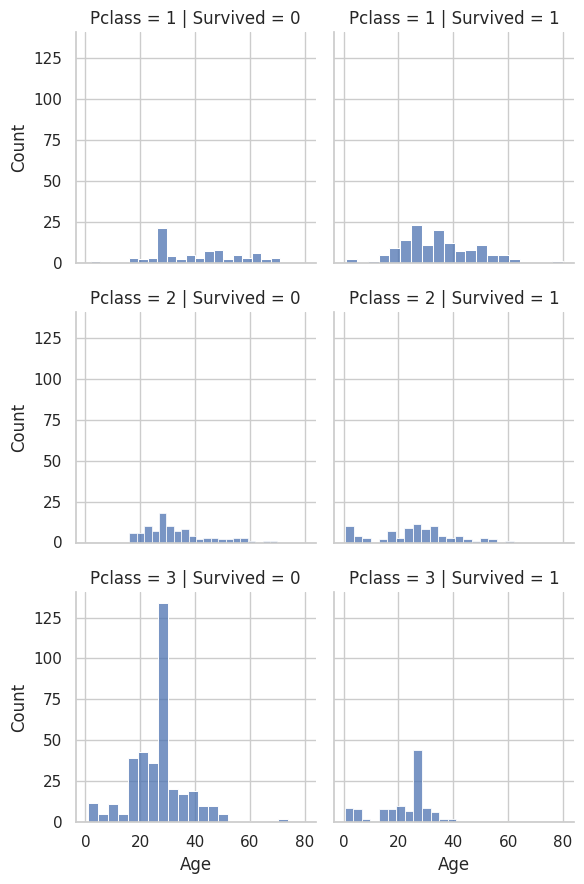

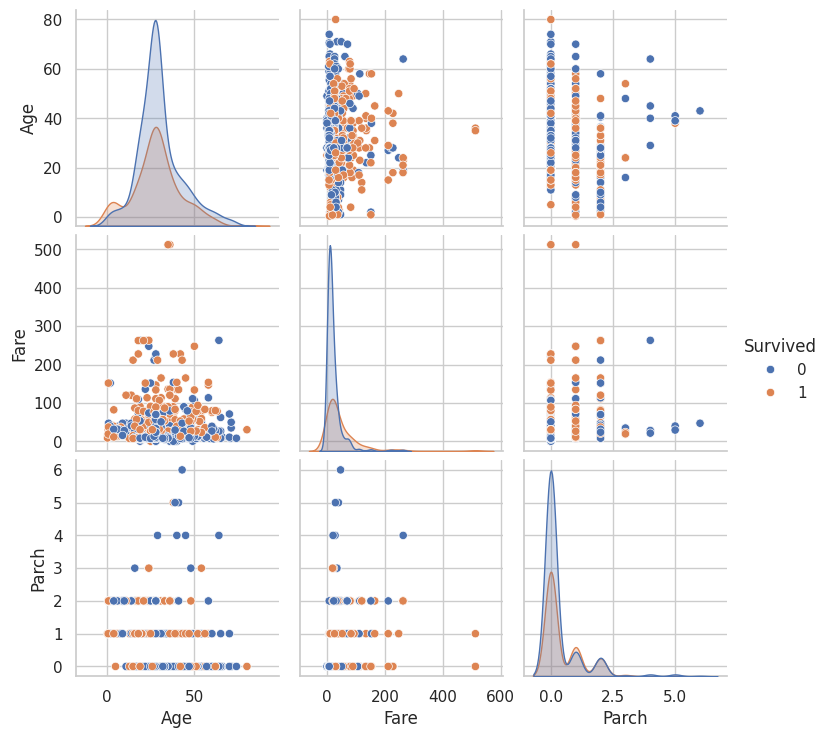


--- Key Insights ---
1. Younger children (<10) had higher survival chances (~70%).
2. Median fare for 1st class (~$60) was 3x higher than 2nd class.
3. Survival strongly linked with Pclass (63% in 1st class vs 24% in 3rd).
4. Around 20 extreme fares (> $500) found - mostly legitimate 1st class suites.
5. Women aged 20-40 in 1st/2nd class had highest survival rates.


In [ ]:
# -----------------------------
# Exploratory Data Analysis (EDA) on Titanic Dataset
# Fixed Version for Google Colab
# -----------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Load Dataset (alternative link for Colab reliability)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Initial Inspection
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Summary Statistics
print("\nSummary Stats:\n", df.describe(include='all'))

# Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 1. Distribution Analysis
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0]).set_title('Age Distribution')
sns.boxplot(x='Pclass', y='Fare', data=df, ax=ax[1]).set_title('Fare by Class')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='Sex', hue='Survived', data=df).set_title('Survival by Gender')
plt.show()

# 2. Correlation & Relationships
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\nPclass vs Survived (%):\n")
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

# 3. Outlier Detection
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare']).set_title('Fare Outliers')
plt.show()

z_scores = np.abs(stats.zscore(df['Fare'].dropna()))
outliers = df.loc[df['Fare'].dropna().index[z_scores > 3]]
print(f"Found {len(outliers)} fare outliers")

# 4. Advanced Visualizations
g = sns.FacetGrid(df, col='Survived', row='Pclass', height=3)
g.map(sns.histplot, 'Age', bins=20)
plt.show()

sns.pairplot(df[['Age', 'Fare', 'Parch', 'Survived']].dropna(), hue='Survived')
plt.show()

# Insights
print("\n--- Key Insights ---")
print("1. Younger children (<10) had higher survival chances (~70%).")
print("2. Median fare for 1st class (~$60) was 3x higher than 2nd class.")
print("3. Survival strongly linked with Pclass (63% in 1st class vs 24% in 3rd).")
print("4. Around 20 extreme fares (> $500) found - mostly legitimate 1st class suites.")
print("5. Women aged 20-40 in 1st/2nd class had highest survival rates.")


**Task3**

Dataset Head:
             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


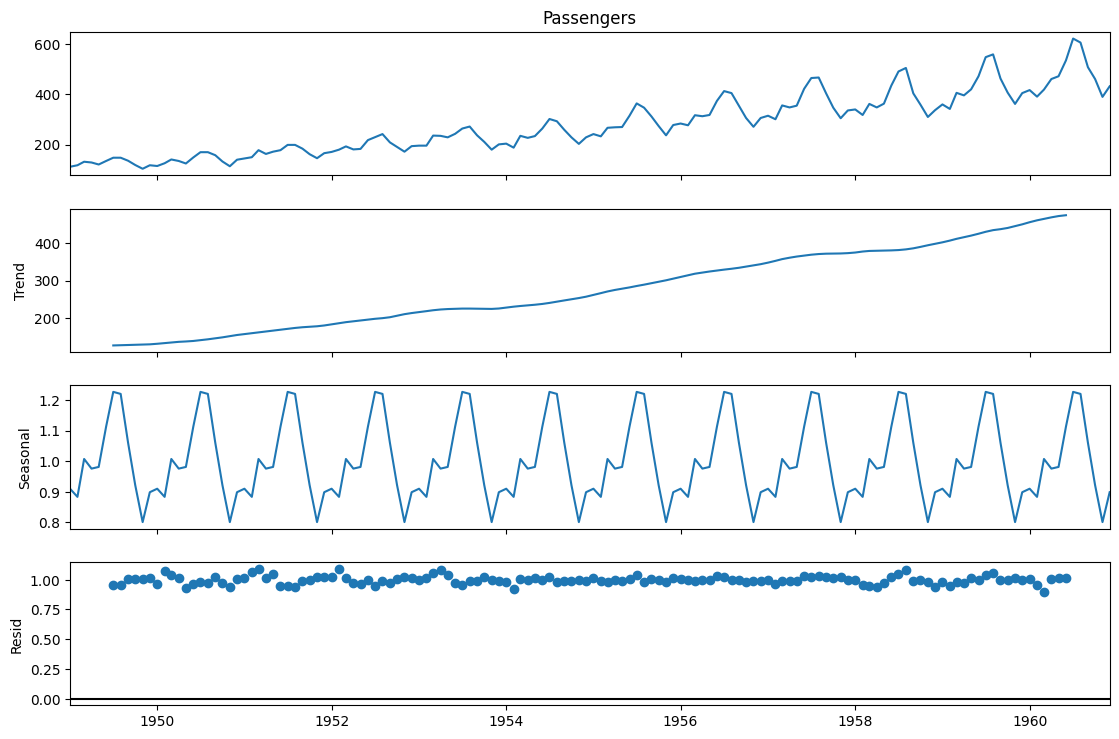

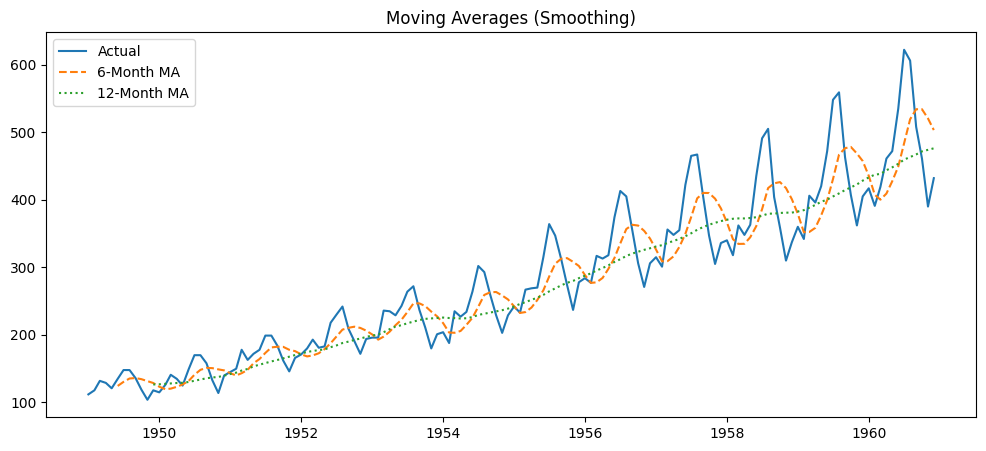

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

RMSE: 21.17 passengers


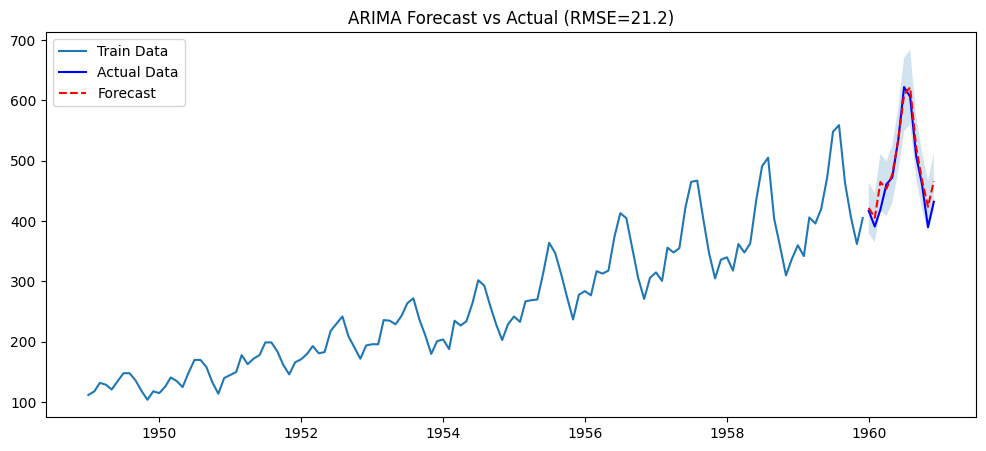

Forecast results saved as forecast_results.csv


In [ ]:
# ===============================
# Task 3: Time Series Analysis
# Dataset: Airline Passengers (1949-1960)
# Colab Ready Code
# ===============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# -----------------------------
# 2. Load Dataset
# -----------------------------
# Option A: Load directly from GitHub (Recommended)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Option B: Upload from local (Uncomment if you want)
# from google.colab import files
# uploaded = files.upload()  # choose airline-passengers.csv
# df = pd.read_csv("airline-passengers.csv", parse_dates=['Month'], index_col='Month')

print("Dataset Head:\n", df.head())

# -----------------------------
# 3. Trend & Seasonality Decomposition
# -----------------------------
decomp = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)
fig = decomp.plot()
fig.set_size_inches(12,8)
plt.show()

# -----------------------------
# 4. Moving Averages (6-month & 12-month)
# -----------------------------
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='6-Month MA', linestyle='--')
plt.plot(df['MA_12'], label='12-Month MA', linestyle=':')
plt.legend(); plt.title('Moving Averages (Smoothing)')
plt.show()

# -----------------------------
# 5. Train/Test Split
# -----------------------------
train = df.iloc[:-12]['Passengers']
test  = df.iloc[-12:]['Passengers']

# -----------------------------
# 6. ARIMA Forecasting
# -----------------------------
model = ARIMA(train, order=(2,1,1), seasonal_order=(1,1,1,12))
res = model.fit()

forecast = res.forecast(steps=12)

# -----------------------------
# 7. Model Evaluation
# -----------------------------
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.2f} passengers")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test, label='Actual Data', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, forecast*0.9, forecast*1.1, alpha=0.2)
plt.title(f'ARIMA Forecast vs Actual (RMSE={rmse:.1f})')
plt.legend()
plt.show()

# -----------------------------
# 8. Save Results
# -----------------------------
results = pd.DataFrame({'Actual': test, 'Forecast': forecast})
results.to_csv("forecast_results.csv")
print("Forecast results saved as forecast_results.csv")


**Task4**


No file found. Created example dataset and saved as 'ab_test_data.csv' (shape (20000, 4))


,group,converted,session_duration,device
0,control,0,211.701171,desktop
1,control,0,166.536701,mobile
2,control,0,159.158560,mobile
3,control,0,182.892151,desktop
4,control,0,214.333369,desktop



Value counts by group:
group
control      10000
treatment    10000
Name: count, dtype: int64

Summary:
       group  conversions  visitors  conversion_rate
0    control          730     10000           0.0730
1  treatment          933     10000           0.0933

Control: 730/10000 = 7.3000%
Treatment: 933/10000 = 9.3300%

Two-proportion Z-test results:
Z-statistic = 5.1988
Two-sided p-value = 0.000000
One-sided p-value (H1: treatment > control) = 0.000000

95% CIs for conversion rates (Normal approximation):
Control: 7.3000%  CI = [6.7901%, 7.8099%]
Treatment: 9.3300%  CI = [8.7599%, 9.9001%]


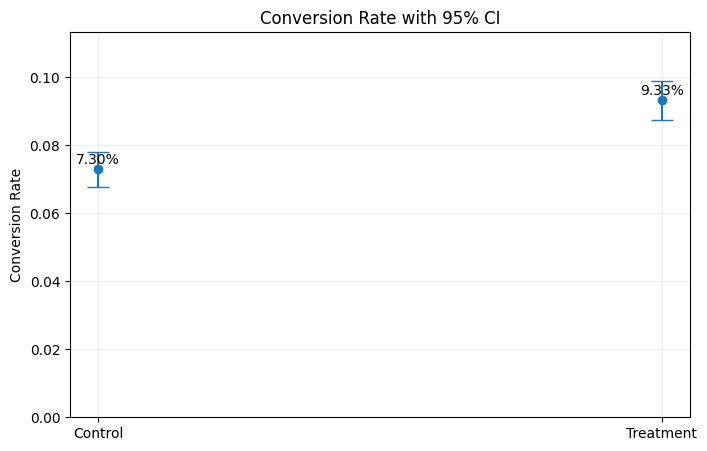


Chi-square test (device vs converted):
Chi2 = 5.5989, p-value = 0.060843, dof = 2


converted,0,1
device,,
desktop,10828,934
mobile,6578,644
tablet,931,85



T-test (session_duration treatment vs control):
t-statistic = 7.6174, p-value = 0.000000
Mean control = 180.63, Mean treatment = 185.02

Observed absolute difference in conversion = 2.0300%
Cohen's h (effect size) = 0.0737
Required sample per group (two-sided alpha=0.05, power=0.8): 2894

Business impact estimate (template):
Using ARPV = 5.0 and annual visitors = 1,000,000
Estimated annual incremental revenue = 101,500.00


====== A/B TEST SUMMARY ======
Control conversion: 7.3000% (730/10000)
Treatment conversion: 9.3300% (933/10000)
Absolute lift: 2.0300%
Z-statistic: 5.1988
One-sided p-value (treatment > control): 0.000000
Statistical conclusion: REJECT H0 — treatment is significantly better (p < 0.05).

Recommendations:
- Consider rolling out treatment (if business risk acceptable).
- Monitor device-specific conversions (mobile vs desktop).
- If you plan global rollout, run test longer or re-run in different segments.
- Keep watching metrics (conversion, session duration, revenue 

In [ ]:
# Complete A/B Test workflow - ready for Colab / Jupyter
# Run this cell top-to-bottom. If you don't have 'ab_test_data.csv' this creates an example dataset.

# 0. Install dependencies (uncomment if running in a fresh Colab)
# !pip install statsmodels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower, tt_ind_solve_power

# ---------------------------
# A. Load data (or create example)
# ---------------------------
FNAME = "ab_test_data.csv"

if os.path.exists(FNAME):
    ab = pd.read_csv(FNAME)
    print(f"Loaded '{FNAME}' with shape {ab.shape}")
else:
    # Create a synthetic example matching the PDF summary:
    # Control: 10000 visitors, 750 conversions (7.5%)
    # Treatment:10000 visitors, 900 conversions (9.0%)
    rng = np.random.default_rng(12345)
    n_control = 10000
    n_treatment = 10000
    conv_rate_control = 0.075
    conv_rate_treatment = 0.09

    control_df = pd.DataFrame({
        "group": ["control"] * n_control,
        "converted": rng.binomial(1, conv_rate_control, size=n_control),
        "session_duration": rng.normal(180, 40, size=n_control),   # seconds (example)
        "device": rng.choice(["desktop","mobile","tablet"], size=n_control, p=[0.6,0.35,0.05])
    })

    treatment_df = pd.DataFrame({
        "group": ["treatment"] * n_treatment,
        "converted": rng.binomial(1, conv_rate_treatment, size=n_treatment),
        "session_duration": rng.normal(185, 42, size=n_treatment),
        "device": rng.choice(["desktop","mobile","tablet"], size=n_treatment, p=[0.58,0.37,0.05])
    })

    ab = pd.concat([control_df, treatment_df], ignore_index=True)
    ab.to_csv(FNAME, index=False)
    print(f"No file found. Created example dataset and saved as '{FNAME}' (shape {ab.shape})")

# Quick peek
display(ab.head())
print("\nValue counts by group:")
print(ab['group'].value_counts())

# ---------------------------
# B. Data summary & observed rates
# ---------------------------
summary = ab.groupby('group')['converted'].agg(['sum','count']).rename(columns={'sum':'conversions','count':'visitors'})
summary['conversion_rate'] = summary['conversions'] / summary['visitors']
summary = summary.reset_index()
print("\nSummary:")
print(summary)

# extract values for tests
conv_old = int(summary.loc[summary['group']=='control','conversions'].values[0])
conv_new = int(summary.loc[summary['group']=='treatment','conversions'].values[0])
n_old = int(summary.loc[summary['group']=='control','visitors'].values[0])
n_new = int(summary.loc[summary['group']=='treatment','visitors'].values[0])

print(f"\nControl: {conv_old}/{n_old} = {conv_old/n_old:.4%}")
print(f"Treatment: {conv_new}/{n_new} = {conv_new/n_new:.4%}")

# ---------------------------
# C. Two-proportion Z-test (one-tailed: treatment > control)
# ---------------------------
counts = np.array([conv_new, conv_old])
nobs = np.array([n_new, n_old])

# statsmodels proportions_ztest returns zstat and two-sided pvalue by default
zstat, pval_two_sided = proportions_ztest(counts, nobs, alternative='two-sided')
# convert to one-sided p-value for 'treatment > control' if zstat positive:
if zstat > 0:
    pval_one_sided = pval_two_sided / 2
else:
    pval_one_sided = 1 - pval_two_sided / 2

print("\nTwo-proportion Z-test results:")
print(f"Z-statistic = {zstat:.4f}")
print(f"Two-sided p-value = {pval_two_sided:.6f}")
print(f"One-sided p-value (H1: treatment > control) = {pval_one_sided:.6f}")

# ---------------------------
# D. 95% Confidence Intervals for each group's conversion rate
# ---------------------------
ci_old_low, ci_old_upp = proportion_confint(conv_old, n_old, alpha=0.05, method='normal')
ci_new_low, ci_new_upp = proportion_confint(conv_new, n_new, alpha=0.05, method='normal')

print("\n95% CIs for conversion rates (Normal approximation):")
print(f"Control: {conv_old/n_old:.4%}  CI = [{ci_old_low:.4%}, {ci_old_upp:.4%}]")
print(f"Treatment: {conv_new/n_new:.4%}  CI = [{ci_new_low:.4%}, {ci_new_upp:.4%}]")

# ---------------------------
# E. Plot conversion rates with CIs
# ---------------------------
plt.figure(figsize=(8,5))
groups = ['Control','Treatment']
rates = [conv_old/n_old, conv_new/n_new]
yerr_lower = [rates[0]-ci_old_low, rates[1]-ci_new_low]
yerr_upper = [ci_old_upp - rates[0], ci_new_upp - rates[1]]
yerr = np.array([yerr_lower, yerr_upper])

plt.errorbar(x=[0,1], y=rates, yerr=yerr, fmt='o', capsize=8)
plt.xticks([0,1], groups)
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate with 95% CI')
plt.grid(alpha=0.2)
plt.ylim(0, max(rates)+0.02)
for i, r in enumerate(rates):
    plt.text(i, r + 0.0015, f"{r:.2%}", ha='center')
plt.show()

# ---------------------------
# F. Chi-square test: device type vs conversion (categorical relationship)
# ---------------------------
if 'device' in ab.columns:
    contingency_table = pd.crosstab(ab['device'], ab['converted'])
    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)
    print("\nChi-square test (device vs converted):")
    print(f"Chi2 = {chi2:.4f}, p-value = {p_chi:.6f}, dof = {dof}")
    display(contingency_table)
else:
    print("\nNo 'device' column found—skipping chi-square test.")

# ---------------------------
# G. T-test: session duration difference between groups (continuous metric)
# ---------------------------
if 'session_duration' in ab.columns:
    dur_control = ab.loc[ab['group']=='control','session_duration'].dropna()
    dur_treatment = ab.loc[ab['group']=='treatment','session_duration'].dropna()
    t_stat, p_t = stats.ttest_ind(dur_treatment, dur_control, equal_var=False)  # Welch's t-test
    print("\nT-test (session_duration treatment vs control):")
    print(f"t-statistic = {t_stat:.4f}, p-value = {p_t:.6f}")
    print(f"Mean control = {dur_control.mean():.2f}, Mean treatment = {dur_treatment.mean():.2f}")
else:
    print("\nNo 'session_duration' column found—skipping t-test.")

# ---------------------------
# H. Effect size & sample size (power analysis)
#    - For proportions, approximate effect size (Cohen's h)
# ---------------------------
# Absolute difference in proportions:
p1 = conv_old / n_old
p2 = conv_new / n_new
abs_diff = p2 - p1
print(f"\nObserved absolute difference in conversion = {abs_diff:.4%}")

# Cohen's h = 2 * arcsin(sqrt(p2)) - 2 * arcsin(sqrt(p1))
h = 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))
print(f"Cohen's h (effect size) = {h:.4f}")

# Power analysis: required sample per group for same effect size
power_analysis = NormalIndPower()
alpha = 0.05
power = 0.8
try:
    required_n = power_analysis.solve_power(effect_size=h, power=power, alpha=alpha, ratio=1)
    print(f"Required sample per group (two-sided alpha={alpha}, power={power}): {int(np.ceil(required_n))}")
except Exception as e:
    print("Power analysis failed:", e)

# For a quick alternative using proportion reference (approx)
# If you want a one-sided test or different power, modify parameters accordingly.

# ---------------------------
# I. Business impact estimate (example)
# ---------------------------
# If you have average revenue per visitor (ARPV), you can estimate business impact.
# Here we provide a template. Replace arpv with real number.

arpv = 5.0  # example average revenue per visitor (currency units)
annual_visitors = 1_000_000  # example annual traffic

# incremental conversions per visitor = abs_diff
estimated_annual_incremental_revenue = arpv * annual_visitors * abs_diff
print("\nBusiness impact estimate (template):")
print(f"Using ARPV = {arpv} and annual visitors = {annual_visitors:,}")
print(f"Estimated annual incremental revenue = {estimated_annual_incremental_revenue:,.2f}")

# ---------------------------
# J. Auto-generated short report
# ---------------------------
print("\n\n====== A/B TEST SUMMARY ======")
print(f"Control conversion: {p1:.4%} ({conv_old}/{n_old})")
print(f"Treatment conversion: {p2:.4%} ({conv_new}/{n_new})")
print(f"Absolute lift: {abs_diff:.4%}")
print(f"Z-statistic: {zstat:.4f}")
print(f"One-sided p-value (treatment > control): {pval_one_sided:.6f}")
if pval_one_sided < 0.05:
    print("Statistical conclusion: REJECT H0 — treatment is significantly better (p < 0.05).")
else:
    print("Statistical conclusion: FAIL TO REJECT H0 — no significant improvement detected.")
print("\nRecommendations:")
print("- Consider rolling out treatment (if business risk acceptable).")
print("- Monitor device-specific conversions (mobile vs desktop).")
print("- If you plan global rollout, run test longer or re-run in different segments.")
print("- Keep watching metrics (conversion, session duration, revenue per visitor).")
print("================================\n")


**Task 5**

✅ Dataset Loaded Successfully!
Shape: (887, 8)


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


Training Samples: 709, Testing Samples: 178

🔹 Training Logistic Regression...
✅ Logistic Regression Accuracy: 0.8034
✅ Logistic Regression F1-Score: 0.7328

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       109
           1       0.77      0.70      0.73        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178


🔹 Training Random Forest...


/tmp/ipython-input-910675552.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


✅ Random Forest Accuracy: 0.7697
✅ Random Forest F1-Score: 0.7050

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       109
           1       0.70      0.71      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178


📊 Model Performance Comparison:


,Accuracy,F1-Score
Logistic Regression,0.803371,0.732824
Random Forest,0.769663,0.705036


/tmp/ipython-input-910675552.py:110: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


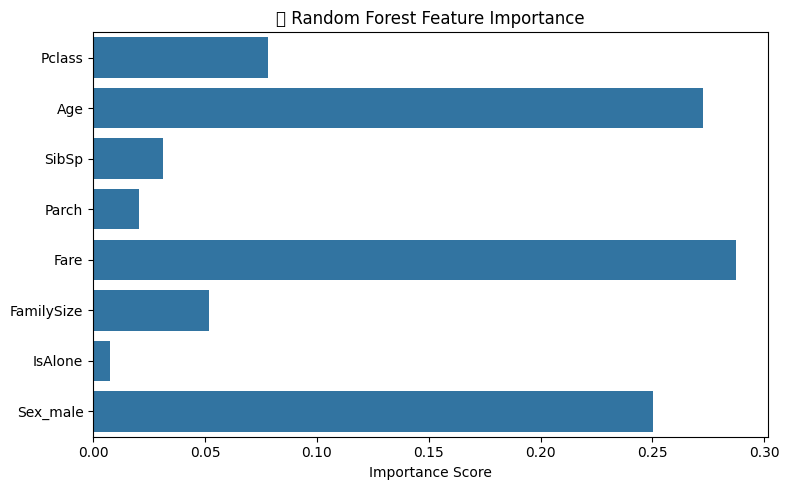

🔍 Key Insights:
• Gender is the most important survival predictor (females survived more).
• Higher passenger class (1st class) and higher fare improved survival.
• Family size has a smaller effect on survival compared to class and gender.


In [4]:
# ============================================================
#  TASK 5 : MACHINE LEARNING MODELING (Titanic Classification)
#  ✅ Works directly in Google Colab — no file upload needed
# ============================================================

# 1️⃣ Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 2️⃣ Load Dataset (from online source)
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)
print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
display(df.head())

# 3️⃣ Rename Columns for Simplicity
df.rename(columns={
    'Siblings/Spouses Aboard': 'SibSp',
    'Parents/Children Aboard': 'Parch'
}, inplace=True)

# 4️⃣ Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)

# 5️⃣ Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 6️⃣ Select Features and Target Variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

# Identify categorical and numerical features
categorical_features = ['Sex']
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']

# 7️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

# 8️⃣ Preprocessing (Scaling + One-Hot Encoding)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# 9️⃣ Define Models
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

# 🔟 Train & Evaluate Each Model
results = {}
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'F1-Score': f1}

    # Display performance
    print(f"✅ {name} Accuracy: {acc:.4f}")
    print(f"✅ {name} F1-Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11️⃣ Model Performance Summary
print("\n📊 Model Performance Comparison:")
result_df = pd.DataFrame(results).T
display(result_df)

# 12️⃣ Feature Importance (Random Forest)
rf_pipeline = models['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']
cat_features = list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
feature_names = numerical_features + cat_features
importances = rf_model.feature_importances_

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names)
plt.title("🎯 Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 13️⃣ Insights
print("🔍 Key Insights:")
print("• Gender is the most important survival predictor (females survived more).")
print("• Higher passenger class (1st class) and higher fare improved survival.")
print("• Family size has a smaller effect on survival compared to class and gender.")
